<a href="https://colab.research.google.com/github/prateesh10/PRODIGY_DS_03/blob/main/PRODIGY_DS_03.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
from sklearn import tree

In [ ]:
url = "/content/bank.csv"
df = pd.read_csv(url, sep=';')
print(df.head())
print(df.info())

   age          job  marital  education default  balance housing loan  \
0   30   unemployed  married    primary      no     1787      no   no   
1   33     services  married  secondary      no     4789     yes  yes   
2   35   management   single   tertiary      no     1350     yes   no   
3   30   management  married   tertiary      no     1476     yes  yes   
4   59  blue-collar  married  secondary      no        0     yes   no   

    contact  day month  duration  campaign  pdays  previous poutcome   y  
0  cellular   19   oct        79         1     -1         0  unknown  no  
1  cellular   11   may       220         1    339         4  failure  no  
2  cellular   16   apr       185         1    330         1  failure  no  
3   unknown    3   jun       199         4     -1         0  unknown  no  
4   unknown    5   may       226         1     -1         0  unknown  no  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4521 entries, 0 to 4520
Data columns (total 17 columns):
 #  

In [ ]:
X = df.drop(columns=['y'])
y = df['y']

le = LabelEncoder()
y = le.fit_transform(y)

X = pd.get_dummies(X, drop_first=True)

print(f"Features shape after encoding: {X.shape}")

Features shape after encoding: (4521, 42)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
clf = DecisionTreeClassifier(criterion='entropy', max_depth=5, random_state=42)

clf.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=5, random_state=42)

In [ ]:
y_pred = clf.predict(X_test)

print("--- Evaluation Results ---")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.4f}\n")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['No Purchase', 'Purchase']))

--- Evaluation Results ---
Accuracy Score: 0.8994

Confusion Matrix:
[[772  35]
 [ 56  42]]

Classification Report:
              precision    recall  f1-score   support

 No Purchase       0.93      0.96      0.94       807
    Purchase       0.55      0.43      0.48        98

    accuracy                           0.90       905
   macro avg       0.74      0.69      0.71       905
weighted avg       0.89      0.90      0.89       905



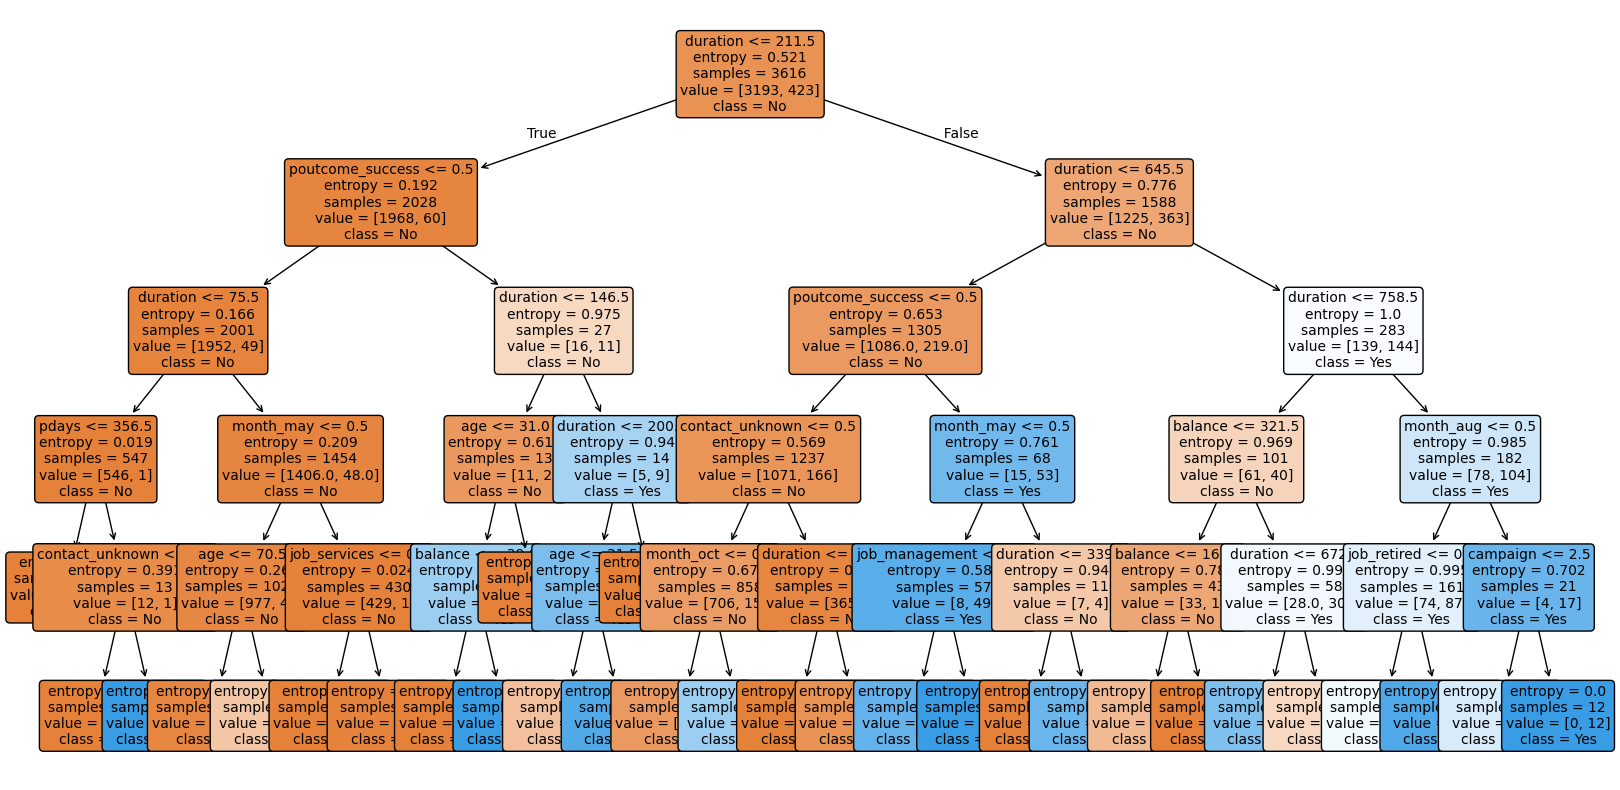

In [ ]:
plt.figure(figsize=(20,10))
tree.plot_tree(clf, feature_names=list(X.columns),
              class_names=['No', 'Yes'], filled=True, rounded=True, fontsize=10)
plt.show()